In [2]:
# packages
using Markdown
using InteractiveUtils
using NonlinearSolve
using Plots

# files
using PKAssetPrices

[ Info: Precompiling PKAssetPrices [5fa4aa55-4e4c-4901-99b7-08200d3ce2d7] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:

params = SimplePKModelParams(c = 0.8, b = 0.5, d_0 = 5)


SimplePKModelParams(0.5, 0.8, 5.0, 0.8, 0.01, 0.5, 0.15, 0.3, 0.15, 2.0, 0.8, 0.8, 12.0)

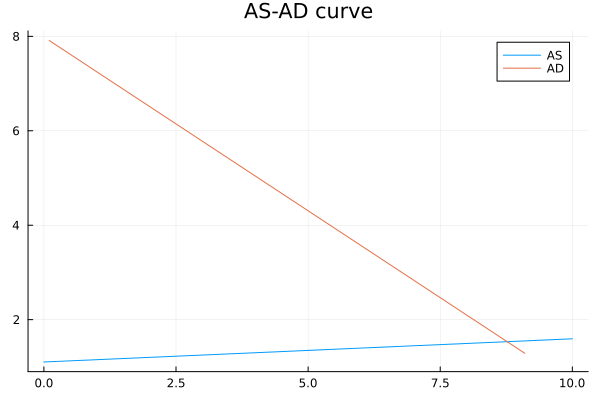

In [4]:
begin
	plot(range(0,10,10),y -> as_curve(y,params), label = "AS", title = "AS-AD curve")
	plot!(range(0.10,10), p -> ad_curve(p,params), label = "AD")
end

In [5]:
model = SimplePKModel()
sol = solve_model(model)
sheets = get_balance_sheets(sol, model.params)
display_all_balance_sheets(sheets)


  PRIVATE SECTOR
┌──────────────┬───────┬─────────────┬───────┐
│ Assets       │ Value │ Liabilities │ Value │
├──────────────┼───────┼─────────────┼───────┤
│ Deposits (D) │  3.46 │ Loans (L)   │  3.46 │
│ Total Assets │  3.46 │ Net Worth   │   0.0 │
└──────────────┴───────┴─────────────┴───────┘

  BANKING SECTOR
┌──────────────┬───────┬────────────────────────┬───────┐
│ Assets       │ Value │ Liabilities            │ Value │
├──────────────┼───────┼────────────────────────┼───────┤
│ Loans (L)    │  3.46 │ Central Bank Money (M) │  1.04 │
│ Reserves (R) │  1.04 │ Deposits (D)           │  3.46 │
│ Total Assets │   4.5 │ Net Worth              │   0.0 │
└──────────────┴───────┴────────────────────────┴───────┘

  CENTRAL BANK
┌──────────────┬───────┬──────────────────┬───────┐
│ Assets       │ Value │ Liabilities      │ Value │
├──────────────┼───────┼──────────────────┼───────┤
│ Reserves (R) │  1.04 │ Money Supply (M) │  1.04 │
│ Total Assets │  1.04 │ Net Worth        │   0.0 │


In [12]:
sheets

LoadError: UndefVarError: `sheets` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

### Alte Sachen, die nicht so recht geholfen haben ein dynamisches Environment bereitzustellen

In [2]:
using PyCall

@pyimport ipywidgets as widgets
@pyimport IPython.display as Pdisplay

# Create sliders
c_slider = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="c")
b_slider = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="b")
d0_slider = widgets.FloatSlider(min=0, max=10, step=0.1, value=5.0, description="d0")

# Display
Pdisplay.display(widgets.VBox([c_slider, b_slider, d0_slider]))

In [8]:
using IJulia
using PyCall

Pwidgets = pyimport("ipywidgets")

# Create sliders
c_slider = Pwidgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="c")
b_slider = Pwidgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="b")
d0_slider = Pwidgets.FloatSlider(min=0, max=10, step=0.1, value=5.0, description="d0")

# Display (this should work in IJulia)
vbox=display(Pwidgets.VBox([c_slider, b_slider, d0_slider]))

Main.IJulia.display(vbox)
display(vbox)

PyObject VBox(children=(FloatSlider(value=0.5, description='c', max=1.0, step=0.01), FloatSlider(value=0.5, description='b', max=1.0, step=0.01), FloatSlider(value=5.0, description='d0', max=10.0)))

nothing

nothing

In [4]:
using WGLMakie, Makie

a = Observable(1)
b = Observable(1)

f(a, b) = sin(a*b)

fig = Figure()

ax = Axis(fig[1, 1])
lines!(ax, 0..10, x -> sin(a[] * x))

sl1 = Slider(fig[2, 1], range=1:5, startvalue=1)
sl2 = Slider(fig[3, 1], range=1:5, startvalue=1)

on(sl1.value) do v
    a[] = v
end

on(sl2.value) do v
    b[] = v
end

fig

In [5]:
f(a, b) = sin(a*b)

@bind a Slider(1:5)
@bind b Slider(1:5)

f(a, b)


LoadError: LoadError: UndefVarError: `@bind` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /Users/joko/Git/MoneyModelFranz/PKAssetPrices/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:3

In [4]:
begin
	plot(range(0,10,10),y -> as_curve(y,params), label = "AS", title = "AS-AD curve")
	plot!(range(0.10,10), p -> ad_curve(p,params), label = "AD")
end

UndefVarError: UndefVarError: `params` not defined in `Main`
Suggestion: check for spelling errors or missing imports.